# AI Job Market Salary Predictor
---

**Mission** 

My mission is to lift Africa out of poverty by educating and inspiring 
the young generation, equipping them with in-demand skills required to earn them an 
income and creating a foundation that will continue to do this even after I die.

This project serves that mission directly by analysing the Global AI Job Market, 
we identify what truly drives salary in the AI industry giving aspiring 
professionals from underrepresented regions the knowledge to make informed, 
strategic career decisions.

**Target Variable** 

`salary_usd` — Annual salary in US Dollars 


**Dataset** 

Global AI Job Market & Salary Trends 2025 (Kaggle)  


**Models** 

Linear Regression · Decision Tree · Tuned Decision Tree · Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ai_job_dataset.csv')

df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


# Feature Engineering
---
Raw data is rarely model-ready. In this section we clean and feature engineer the dataset into a format our models can learn from. This involves dropping irrelevant columns, encoding categorical variables, extracting skills, and mapping locations to broader regions.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [4]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


## 1. Dropping Irrelevant Columns

Some columns carry no predictive signal for salary and would only add noise. We drop identifiers, redundant salary representations, and date fields that don't contribute meaningful patterns.

In [5]:
df = df.drop(columns=['job_id', 'salary_currency', 'posting_date', 'application_deadline', 'company_name'])

df.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,job_description_length,benefits_score
0,AI Research Scientist,90376,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,1076,5.9
1,AI Software Engineer,61895,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,1268,5.2
2,AI Specialist,152626,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,1974,9.4
3,NLP Engineer,80215,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,1345,8.6
4,AI Consultant,54624,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,1989,6.6


## 2. Ordinal Encoding
--------

While "One Hot Encoding" is a common and default method for encoding categorical variables, it can be computationally expensive.

However, Ordinal Encoding comes in when there is an inherent order to the categories, once there is an inherent order, we can assign a number to each category, this makes the encoding super efficient.

The following columns have a natural order to their categories, this means the categories have an inherent ranking from low to high. 

For these, we use ordinal encoding (assigning integers that preserve the order) rather than one-hot encoding, which would incorrectly treat them as unrelated categories.

In [6]:
print(f"Unique Education values - {df['education_required'].unique()}")

print(f"Unique Experience Level values - {df['experience_level'].unique()}")

print(f"Unique Company Size values - {df['company_size'].unique()}")

Unique Education values - ['Bachelor' 'Master' 'Associate' 'PhD']
Unique Experience Level values - ['SE' 'EN' 'MI' 'EX']
Unique Company Size values - ['M' 'L' 'S']


In [7]:
education_order = {
    'Associate': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

df['education_required'] = df['education_required'].map(education_order)

experience_order = {
    'EN': 0, 
    'MI': 1, 
    'SE': 2, 
    'EX': 3
}    

df['experience_level'] = df['experience_level'].map(experience_order)


size_order = {
    'S': 0, 
    'M': 1, 
    'L': 2
}

df['company_size'] = df['company_size'].map(size_order)

df.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,job_description_length,benefits_score
0,AI Research Scientist,90376,2,CT,China,1,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",1,9,Automotive,1076,5.9
1,AI Software Engineer,61895,0,CT,Canada,1,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",2,1,Media,1268,5.2
2,AI Specialist,152626,1,FL,Switzerland,2,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",0,2,Education,1974,9.4
3,NLP Engineer,80215,2,FL,India,1,India,50,"Scala, SQL, Linux, Python",3,7,Consulting,1345,8.6
4,AI Consultant,54624,0,PT,France,0,Singapore,100,"MLOps, Java, Tableau, Python",2,0,Media,1989,6.6


## 3. Job Title Categorization

There are many unique job titles which would create too many sparse columns if one-hot encoded individually. 

We group them into 5 meaningful categories that capture the nature of the role, then one-hot encode the categories.

In [8]:
df['job_title'].unique()

array(['AI Research Scientist', 'AI Software Engineer', 'AI Specialist',
       'NLP Engineer', 'AI Consultant', 'AI Architect',
       'Principal Data Scientist', 'Data Analyst',
       'Autonomous Systems Engineer', 'AI Product Manager',
       'Machine Learning Engineer', 'Data Engineer', 'Research Scientist',
       'ML Ops Engineer', 'Robotics Engineer', 'Head of AI',
       'Deep Learning Engineer', 'Data Scientist',
       'Machine Learning Researcher', 'Computer Vision Engineer'],
      dtype=object)

In [9]:
job_category_map = {
    'AI Research Scientist': 'Research',
    'Research Scientist': 'Research',
    'Machine Learning Researcher': 'Research',
    
    'AI Software Engineer': 'Engineering',
    'Machine Learning Engineer': 'Engineering',
    'Deep Learning Engineer': 'Engineering',
    'NLP Engineer': 'Engineering',
    'Computer Vision Engineer': 'Engineering',
    'Autonomous Systems Engineer': 'Engineering',
    'Robotics Engineer': 'Engineering',
    'Data Engineer': 'Engineering',
    'ML Ops Engineer': 'Engineering',
    
    'Data Scientist': 'Data & Analytics',
    'Principal Data Scientist': 'Data & Analytics',
    'Data Analyst': 'Data & Analytics',
    
    'Head of AI': 'Leadership & Strategy',
    'AI Architect': 'Leadership & Strategy',
    'AI Product Manager': 'Leadership & Strategy',
    'AI Consultant': 'Leadership & Strategy',
    
    'AI Specialist': 'Specialist'
}

df['job_category'] = df['job_title'].map(job_category_map)

df = df.drop('job_title', axis=1)

df = pd.get_dummies(df, columns=['job_category'], drop_first=True, dtype=int)

df.head()

,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,job_description_length,benefits_score,job_category_Engineering,job_category_Leadership & Strategy,job_category_Research,job_category_Specialist
0,90376,2,CT,China,1,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",1,9,Automotive,1076,5.9,0,0,1,0
1,61895,0,CT,Canada,1,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",2,1,Media,1268,5.2,1,0,0,0
2,152626,1,FL,Switzerland,2,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",0,2,Education,1974,9.4,0,0,0,1
3,80215,2,FL,India,1,India,50,"Scala, SQL, Linux, Python",3,7,Consulting,1345,8.6,1,0,0,0
4,54624,0,PT,France,0,Singapore,100,"MLOps, Java, Tableau, Python",2,0,Media,1989,6.6,0,1,0,0


## 4. Location Categorization

Rather than encoding every country individually (which would create dozens of sparse columns), we map both `company_location` and `employee_residence` to 6 broader geographic regions. 

This preserves the geographic salary signal while keeping the feature space manageable.

In [10]:
print(f"Unique Company Location - {df['company_location'].unique()}\n\n")

print(f"Unique Employee Residence - {df['company_location'].unique()}")

Unique Company Location - ['China' 'Canada' 'Switzerland' 'India' 'France' 'Germany'
 'United Kingdom' 'Singapore' 'Austria' 'Sweden' 'South Korea' 'Norway'
 'Netherlands' 'United States' 'Israel' 'Australia' 'Ireland' 'Denmark'
 'Finland' 'Japan']


Unique Employee Residence - ['China' 'Canada' 'Switzerland' 'India' 'France' 'Germany'
 'United Kingdom' 'Singapore' 'Austria' 'Sweden' 'South Korea' 'Norway'
 'Netherlands' 'United States' 'Israel' 'Australia' 'Ireland' 'Denmark'
 'Finland' 'Japan']


In [11]:
region_map = {
    'United States': 'North America', 
    'Canada': 'North America',

    'Austria': 'Europe', 
    'Germany': 'Europe', 
    'United Kingdom': 'Europe', 
    'France': 'Europe',
    'Netherlands': 'Europe', 
    'Norway': 'Europe', 
    'Sweden': 'Europe',
    'Switzerland': 'Europe', 
    'Ireland': 'Europe', 
    'Denmark': 'Europe',
    'Finland': 'Europe',


    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Singapore': 'Asia',
    'South Korea': 'Asia',

    'Israel': 'Middle East',    
    
    'Australia': 'Oceania', 
}

df['company_region'] = df['company_location'].map(region_map).fillna('Other')

df['employee_region'] = df['employee_residence'].map(region_map).fillna('Other')

df.drop(columns=['company_location', 'employee_residence'], inplace=True)

df = pd.get_dummies(df, columns=['company_region', 'employee_region'], drop_first=True, dtype=int)

df.head()

,salary_usd,experience_level,employment_type,company_size,remote_ratio,required_skills,education_required,years_experience,industry,job_description_length,...,job_category_Research,job_category_Specialist,company_region_Europe,company_region_Middle East,company_region_North America,company_region_Oceania,employee_region_Europe,employee_region_Middle East,employee_region_North America,employee_region_Oceania
0,90376,2,CT,1,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",1,9,Automotive,1076,...,1,0,0,0,0,0,0,0,0,0
1,61895,0,CT,1,100,"Deep Learning, AWS, Mathematics, Python, Docker",2,1,Media,1268,...,0,0,0,0,1,0,1,0,0,0
2,152626,1,FL,2,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",0,2,Education,1974,...,0,1,1,0,0,0,0,0,0,0
3,80215,2,FL,1,50,"Scala, SQL, Linux, Python",3,7,Consulting,1345,...,0,0,0,0,0,0,0,0,0,0
4,54624,0,PT,0,100,"MLOps, Java, Tableau, Python",2,0,Media,1989,...,0,0,1,0,0,0,0,0,0,0


## 5. One-Hot Encoding

For the following columns, the values have no inherent relationship and they number of unique values are manageable, hence we one-hot-encode these columns to boost data spread

In [12]:
print(f"Unique Employment Type - {df['employment_type'].unique()}\n\n")

print(f"Unique Industry - {df['industry'].unique()}")

Unique Employment Type - ['CT' 'FL' 'PT' 'FT']


Unique Industry - ['Automotive' 'Media' 'Education' 'Consulting' 'Healthcare' 'Gaming'
 'Government' 'Telecommunications' 'Manufacturing' 'Energy' 'Technology'
 'Real Estate' 'Finance' 'Transportation' 'Retail']


In [13]:
df = pd.get_dummies(df, columns=['employment_type', 'industry'], drop_first=True, dtype=int)

df.head()

,salary_usd,experience_level,company_size,remote_ratio,required_skills,education_required,years_experience,job_description_length,benefits_score,job_category_Engineering,...,industry_Gaming,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Real Estate,industry_Retail,industry_Technology,industry_Telecommunications,industry_Transportation
0,90376,2,1,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",1,9,1076,5.9,0,...,0,0,0,0,0,0,0,0,0,0
1,61895,0,1,100,"Deep Learning, AWS, Mathematics, Python, Docker",2,1,1268,5.2,1,...,0,0,0,0,1,0,0,0,0,0
2,152626,1,2,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",0,2,1974,9.4,0,...,0,0,0,0,0,0,0,0,0,0
3,80215,2,1,50,"Scala, SQL, Linux, Python",3,7,1345,8.6,1,...,0,0,0,0,0,0,0,0,0,0
4,54624,0,0,100,"MLOps, Java, Tableau, Python",2,0,1989,6.6,0,...,0,0,0,0,1,0,0,0,0,0


## 6. Skills Extraction

The `required_skills` column contains a comma-separated list of skills per row. 

We extract all 24 unique skills and create a binary column for each where the value is 1 if the job requires that skill and 0 if not. 

This is called multi-label binarization.

In [14]:
from collections import Counter

all_skills = df['required_skills'].str.split(',').explode().str.strip()

skill_counter = Counter(all_skills)

# There are 24 skills in total
cleaned_skills = [skill for skill, _ in Counter(all_skills).most_common(24)]

for skill in cleaned_skills:
    df[f'skill_{skill.replace(" ", "_")}'] = df['required_skills'].str.contains(skill, na=False).astype(int)

df.drop(columns=['required_skills'], inplace=True)

df.head()

,salary_usd,experience_level,company_size,remote_ratio,education_required,years_experience,job_description_length,benefits_score,job_category_Engineering,job_category_Leadership & Strategy,...,skill_Data_Visualization,skill_Deep_Learning,skill_MLOps,skill_Spark,skill_NLP,skill_Azure,skill_AWS,skill_Mathematics,skill_Docker,skill_Statistics
0,90376,2,1,50,1,9,1076,5.9,0,0,...,0,0,0,0,1,0,0,0,0,0
1,61895,0,1,100,2,1,1268,5.2,1,0,...,0,1,0,0,0,0,1,1,1,0
2,152626,1,2,0,0,2,1974,9.4,0,0,...,0,1,0,0,1,0,0,0,0,0
3,80215,2,1,50,3,7,1345,8.6,1,0,...,0,0,0,0,0,0,0,0,0,0
4,54624,0,0,100,2,0,1989,6.6,0,1,...,0,0,1,0,0,0,0,0,0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 61 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   salary_usd                          15000 non-null  int64  
 1   experience_level                    15000 non-null  int64  
 2   company_size                        15000 non-null  int64  
 3   remote_ratio                        15000 non-null  int64  
 4   education_required                  15000 non-null  int64  
 5   years_experience                    15000 non-null  int64  
 6   job_description_length              15000 non-null  int64  
 7   benefits_score                      15000 non-null  float64
 8   job_category_Engineering            15000 non-null  int64  
 9   job_category_Leadership & Strategy  15000 non-null  int64  
 10  job_category_Research               15000 non-null  int64  
 11  job_category_Specialist             15000

# Visualizations
---

Before training, we visualize the data to understand distributions, relationships and patterns that will influence how our models learn. 

These visualizations also help us validate our feature engineering decisions.

## Correlation Heatmap

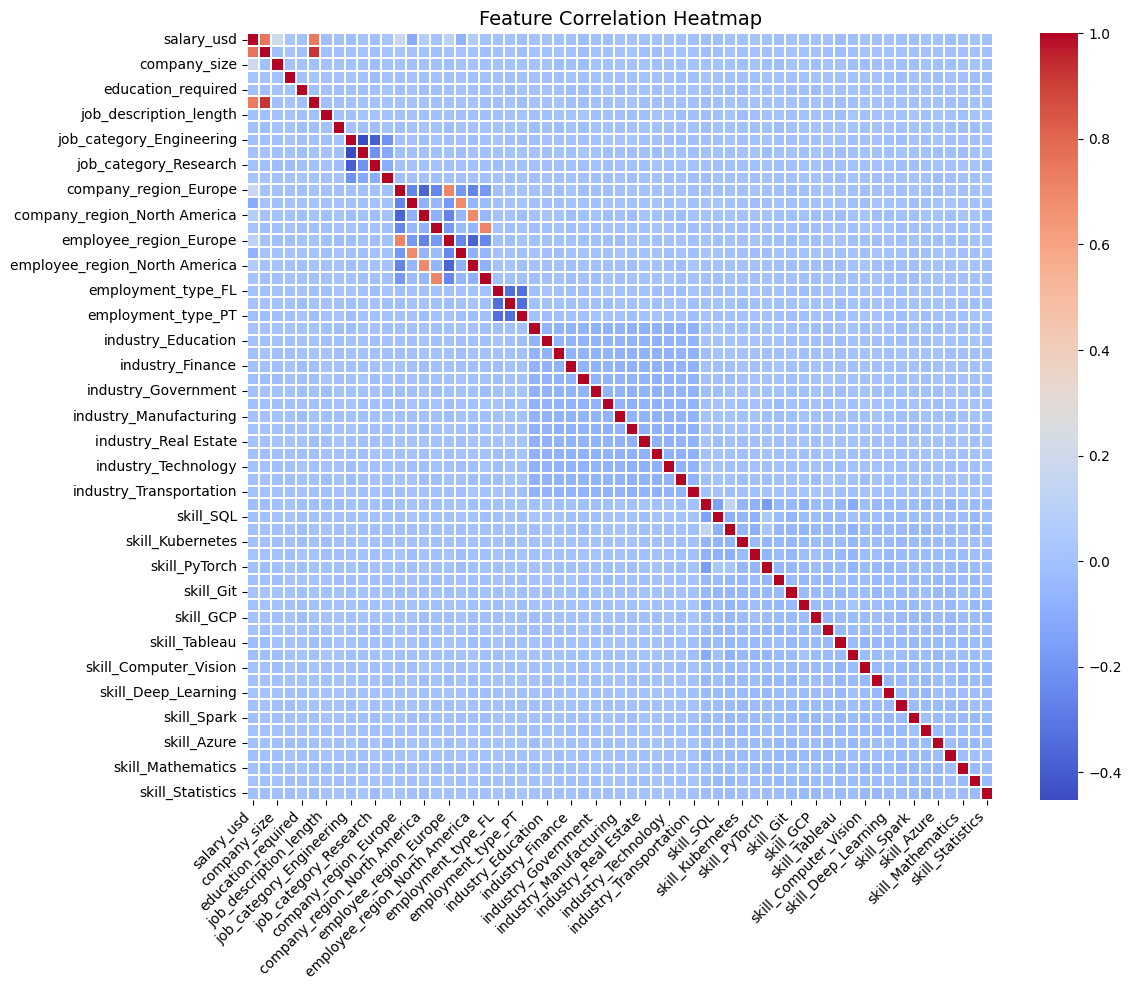

In [16]:
import seaborn as sns

plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=False, fmt='.2f', cmap='coolwarm',
            linewidths=0.3)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Distribution of Target Value

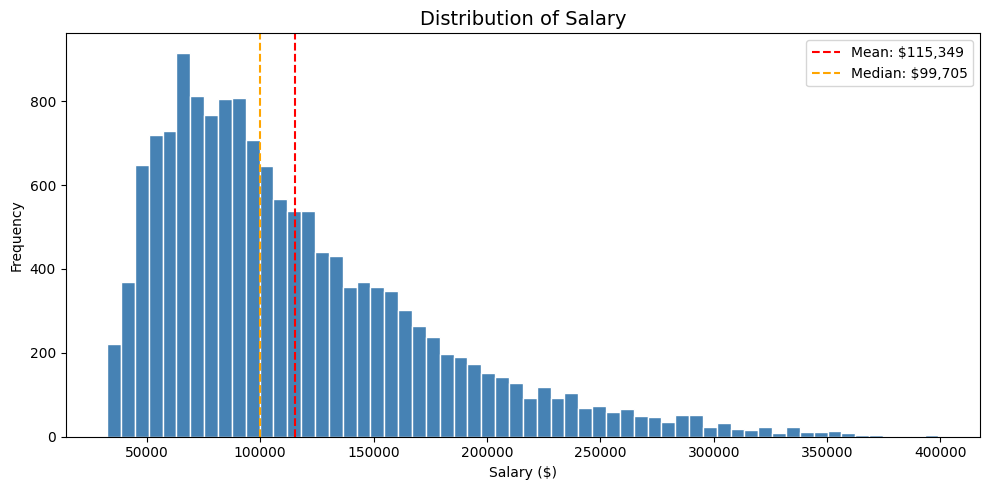

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df['salary_usd'], bins=60, color='steelblue', edgecolor='white')
plt.title('Distribution of Salary', fontsize=14)
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.axvline(df['salary_usd'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['salary_usd'].mean():,.0f}")
plt.axvline(df['salary_usd'].median(), color='orange', linestyle='--',
            label=f"Median: ${df['salary_usd'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

## Average Income by Company Region

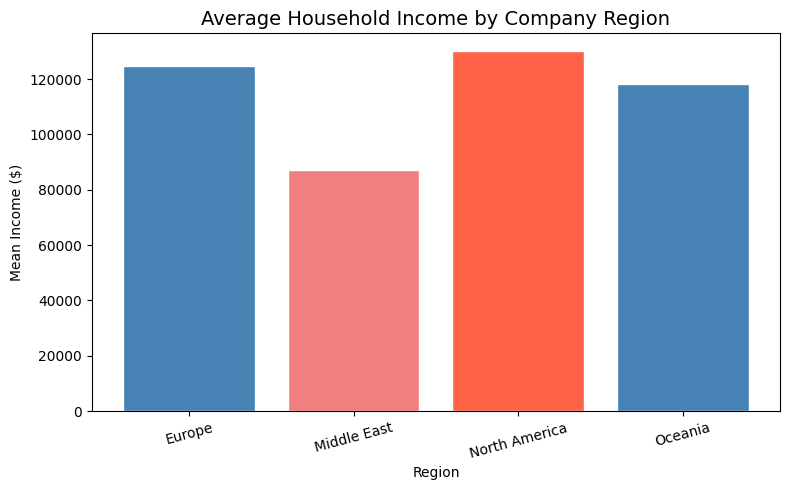

In [18]:
region_cols = [c for c in df.columns if c.startswith('company_region_')]
region_means = {}
for col in region_cols:
    region_means[col.replace('company_region_', '')] = df[df[col] == 1]['salary_usd'].mean()

plt.figure(figsize=(8, 5))
regions = list(region_means.keys())
values  = list(region_means.values())
colors  = ['tomato' if v == max(values) else
           'lightcoral' if v == min(values) else
           'steelblue' for v in values]
plt.bar(regions, values, color=colors, edgecolor='white')
plt.title('Average Household Income by Company Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Mean Income ($)')
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()


## Average Income by Employee Region

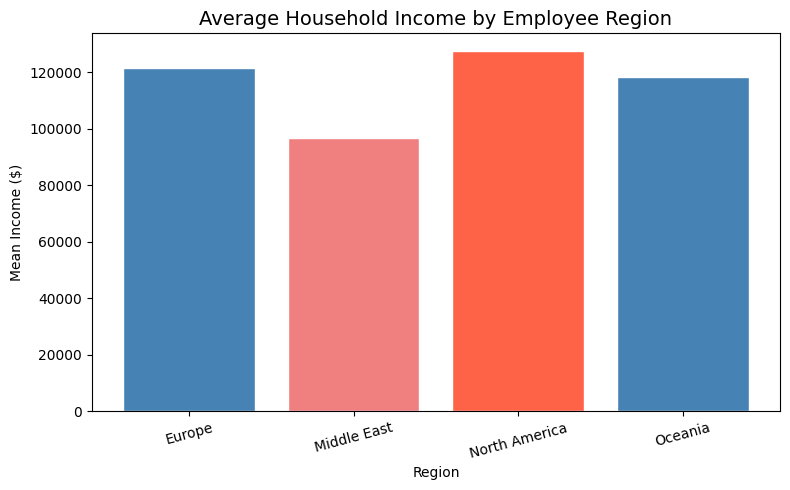

In [19]:
region_cols = [c for c in df.columns if c.startswith('employee_region_')]
region_means = {}
for col in region_cols:
    region_means[col.replace('employee_region_', '')] = df[df[col] == 1]['salary_usd'].mean()

plt.figure(figsize=(8, 5))
regions = list(region_means.keys())
values  = list(region_means.values())
colors  = ['tomato' if v == max(values) else
           'lightcoral' if v == min(values) else
           'steelblue' for v in values]
plt.bar(regions, values, color=colors, edgecolor='white')
plt.title('Average Household Income by Employee Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Mean Income ($)')
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()


## Data Splitting

In [20]:
x = df.drop(['salary_usd'], axis=1)

y = df['salary_usd']

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Data Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test  = scaler.transform(x_test)

# Linear Regression Model Implementation

Now we implement the linear regression model using the cleaned data.

In [23]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

lin_y_pred = lin_model.predict(x_test)

r2 = r2_score(y_test, lin_y_pred)

print(f'Model Accuracy (R²): {r2 * 100:.2f}%')

Model Accuracy (R²): 67.61%


## Bias / Variance Analysis — Learning Curve

The learning curve plots training error and cross-validation error against training size. 

Converging curves indicate good generalization, a large gap indicates overfitting.

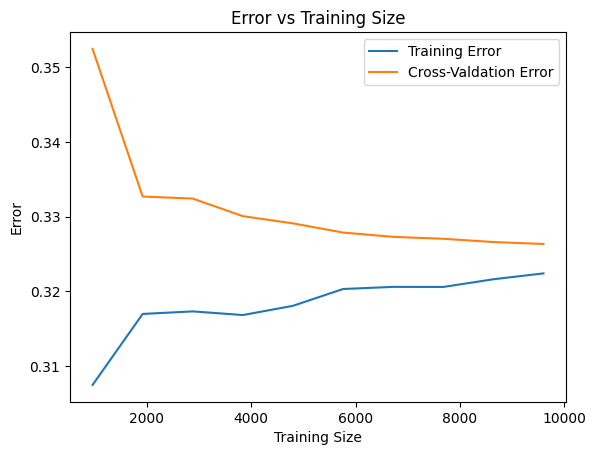

In [25]:
from sklearn.model_selection import learning_curve

lin_train_sizes, lin_train_scores, lin_valid_scores = learning_curve(
    lin_model, x_train, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

lin_train_error = 1 - lin_train_scores.mean(axis=1)

lin_valid_error = 1 - lin_valid_scores.mean(axis=1)

plt.plot(lin_train_sizes, lin_train_error, label='Training Error')

plt.plot(lin_train_sizes, lin_valid_error, label='Cross-Valdation Error')

plt.legend()

plt.xlabel('Training Size')

plt.ylabel('Error')

plt.title("Error vs Training Size")

plt.show()

## Feature Coefficients

Linear Regression assigns a coefficient to each feature representing its impact on salary in USD. 

Positive coefficients increase the predicted salary, negative ones decrease it. 

This gives us direct explanation into what the model has learned.

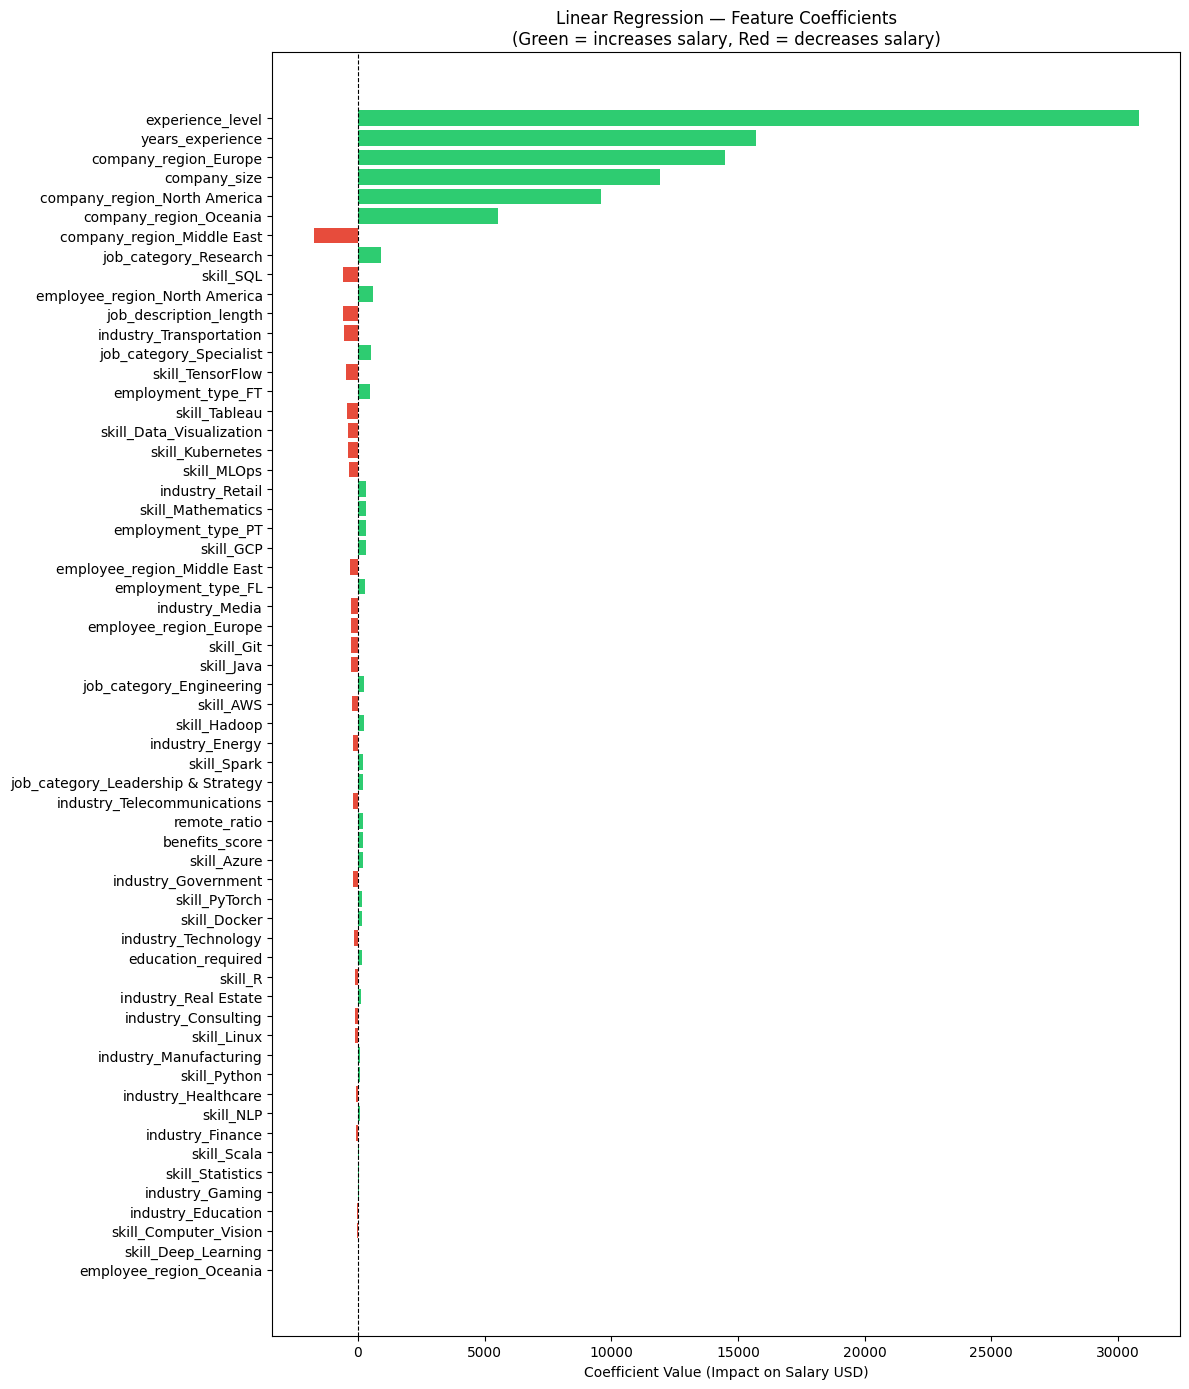

In [26]:
feature_names = x.columns.tolist()
coefficients = lin_model.coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=True)

plt.figure(figsize=(12, 14))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value (Impact on Salary USD)')
plt.title('Linear Regression — Feature Coefficients\n(Green = increases salary, Red = decreases salary)')
plt.tight_layout()
plt.show()

## Scatter Plot

The red dashed line represents perfect predictions (actual = predicted). 

Points close to this line are accurate predictions. 

Points below the line mean the model is underpredicting, points above mean overpredicting.

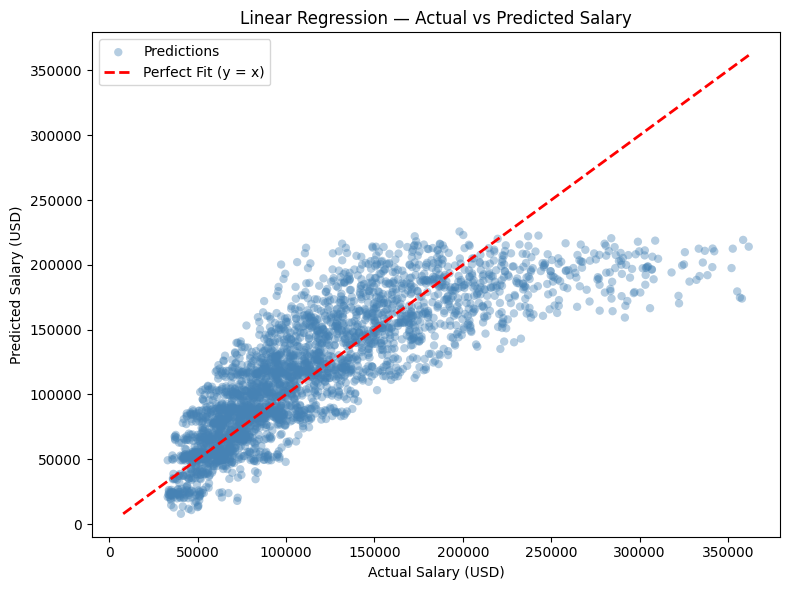

In [27]:
lin_y_pred_plot = lin_model.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, lin_y_pred_plot, alpha=0.4, color='steelblue', edgecolors='none', label='Predictions')

min_val = min(y_test.min(), lin_y_pred_plot.min())
max_val = max(y_test.max(), lin_y_pred_plot.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit (y = x)')

plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title('Linear Regression — Actual vs Predicted Salary')
plt.legend()
plt.tight_layout()
plt.show()

# Decision Tree Regression Implementation
-----

In [28]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
dt_y_pred = dt_model.predict(x_test)

dt_r2 = r2_score(y_test, dt_y_pred)

print(f'Model Accuracy (R²): {dt_r2 * 100:.2f}%')

Model Accuracy (R²): 35.05%


## Bias / Variance Analysis

This untuned Decision tree is expected to show severe overfitting.

Training error near zero while CV error remains high. 

This gap is what hyperparameter tuning is designed to close.

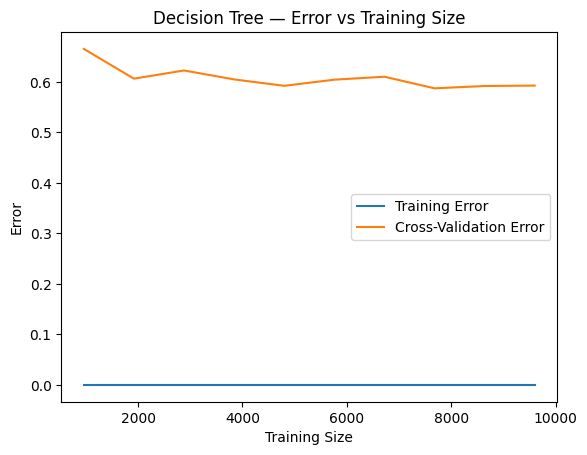

In [30]:
dt_train_sizes, dt_train_scores, dt_valid_scores = learning_curve(
    dt_model, x_train, y_train, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

dt_train_error = 1 - dt_train_scores.mean(axis=1)
dt_valid_error = 1 - dt_valid_scores.mean(axis=1)

plt.figure()
plt.plot(dt_train_sizes, dt_train_error, label='Training Error')
plt.plot(dt_train_sizes, dt_valid_error, label='Cross-Validation Error')
plt.legend()
plt.xlabel('Training Size')
plt.ylabel('Error')
plt.title('Decision Tree — Error vs Training Size')
plt.show()

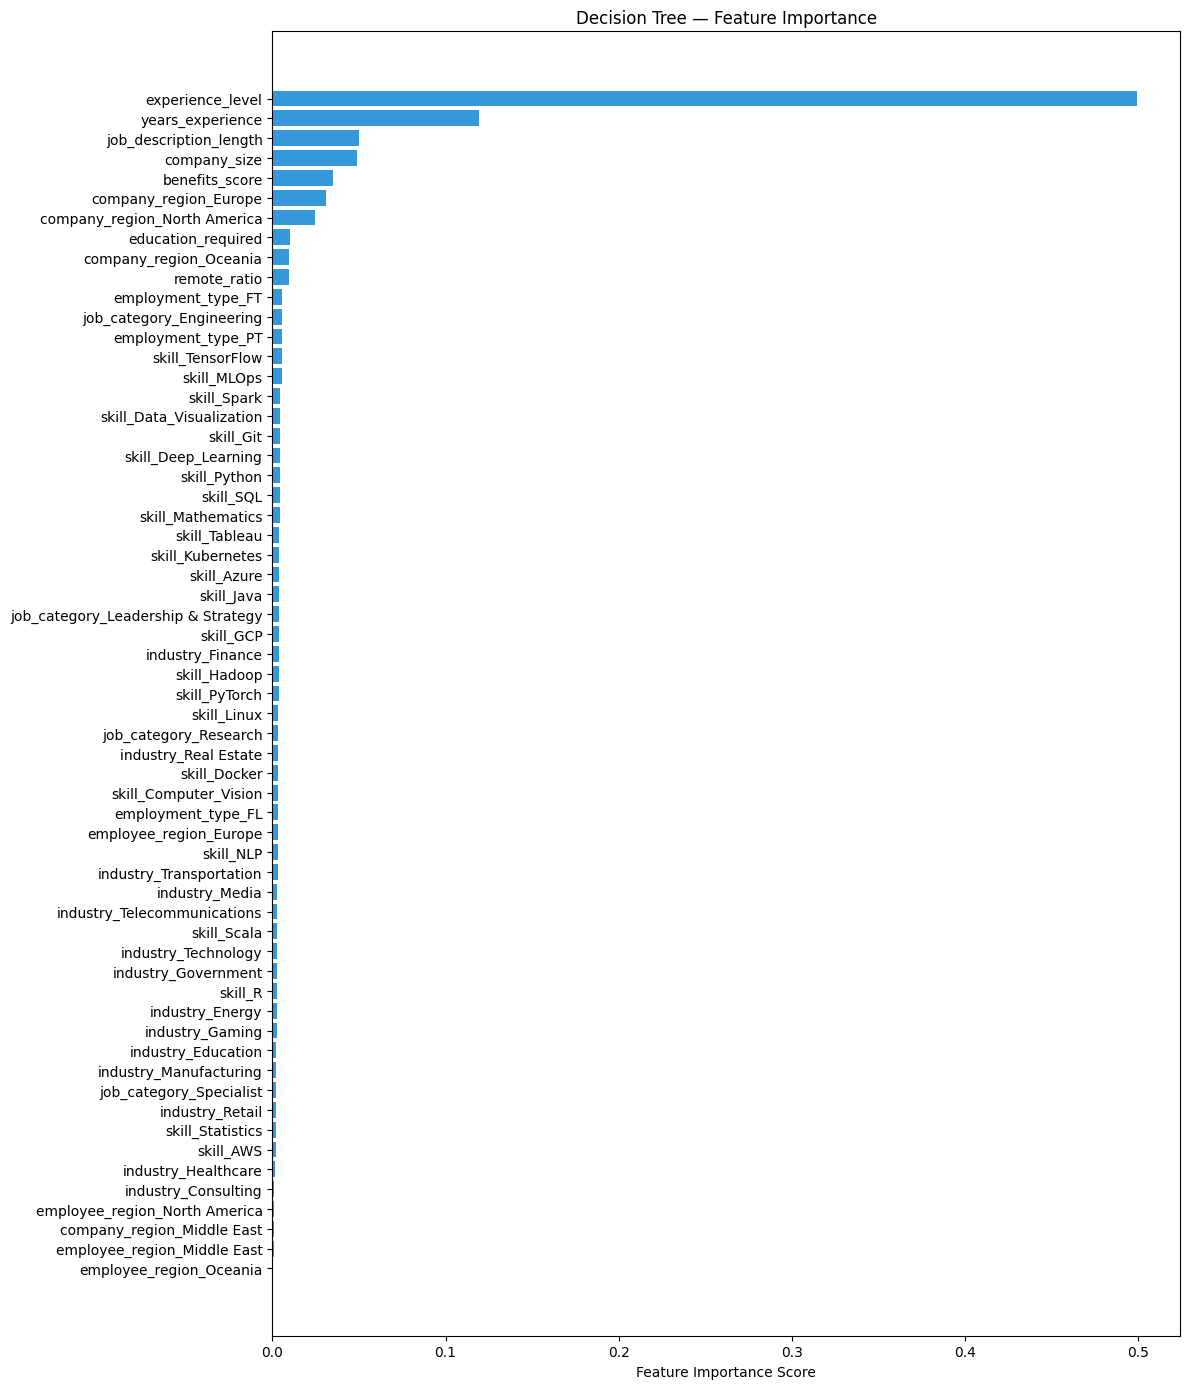

In [31]:
dt_importance = pd.DataFrame({
    'Feature': x.columns.tolist(),
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 14))
plt.barh(dt_importance['Feature'], dt_importance['Importance'], color='#3498db')
plt.xlabel('Feature Importance Score')
plt.title('Decision Tree — Feature Importance')
plt.tight_layout()
plt.show()

# Decision Tree (HyperParamter Tuned) Implementation
-------

`GridSearchCV` systematically searches combinations of hyperparameters using 
5-fold cross-validation to find the configuration that generalizes best. 


The key parameters we tune -

| Parameter | Purpose |
|---|---|
| `max_depth` | Limits tree depth — prevents memorizing noise |
| `min_samples_split` | Minimum samples required to split a node |
| `min_samples_leaf` | Minimum samples required at each leaf node |

**Best found** 

`max_depth=5`, `min_samples_leaf=10`, `min_samples_split=2` → **R²=69.43%**

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20]
}

dt_base = DecisionTreeRegressor(random_state=42)

dt_grid = GridSearchCV(
    dt_base,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(x_train, y_train)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV R²: {dt_grid.best_score_ * 100:.2f}%")

dt_model_hyper = dt_grid.best_estimator_

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV R²: 69.44%


In [33]:
dt_hyper_y_pred = dt_model_hyper.predict(x_test)

dt_hyper_r2 = r2_score(y_test, dt_hyper_y_pred)

print(f'Tuned DT Accuracy (R²): {dt_hyper_r2 * 100:.2f}%')
print(f'Original DT Accuracy (R²): {dt_r2 * 100:.2f}%')
print(f'Improvement: +{(dt_hyper_r2 - dt_r2) * 100:.2f}%')

Tuned DT Accuracy (R²): 69.43%
Original DT Accuracy (R²): 35.05%
Improvement: +34.39%


## Bias / Variance Analysis

With `max_depth=5`, the tree can no longer memorize training data. 

We expect to see training and CV errors converge closely, confirming the overfitting has been resolved.

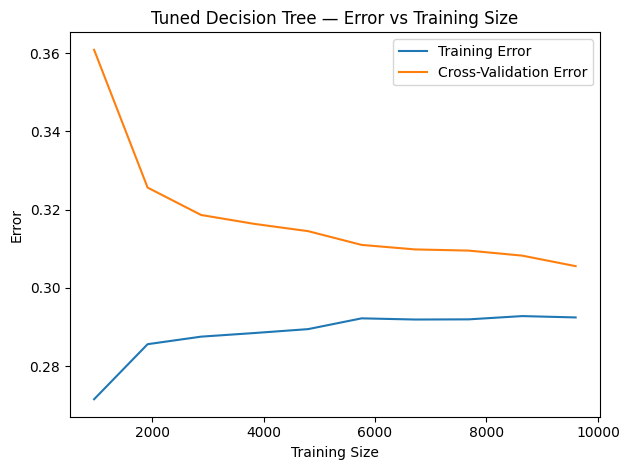

In [34]:
dt_hyper_train_sizes, dt_hyper_train_scores, dt_hyper_valid_scores = learning_curve(
    dt_model_hyper, x_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

dt_hyper_train_error = 1 - dt_hyper_train_scores.mean(axis=1)
dt_hyper_valid_error = 1 - dt_hyper_valid_scores.mean(axis=1)

plt.figure()
plt.plot(dt_hyper_train_sizes, dt_hyper_train_error, label='Training Error')
plt.plot(dt_hyper_train_sizes, dt_hyper_valid_error, label='Cross-Validation Error')
plt.xlabel('Training Size')
plt.ylabel('Error')
plt.title('Tuned Decision Tree — Error vs Training Size')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

Looks like with only 5 levels of splits available, the tuned tree is forced to be ruthlessly selective — using only the features that carry the most predictive power. 

This gives us a clean signal about what truly drives salary.

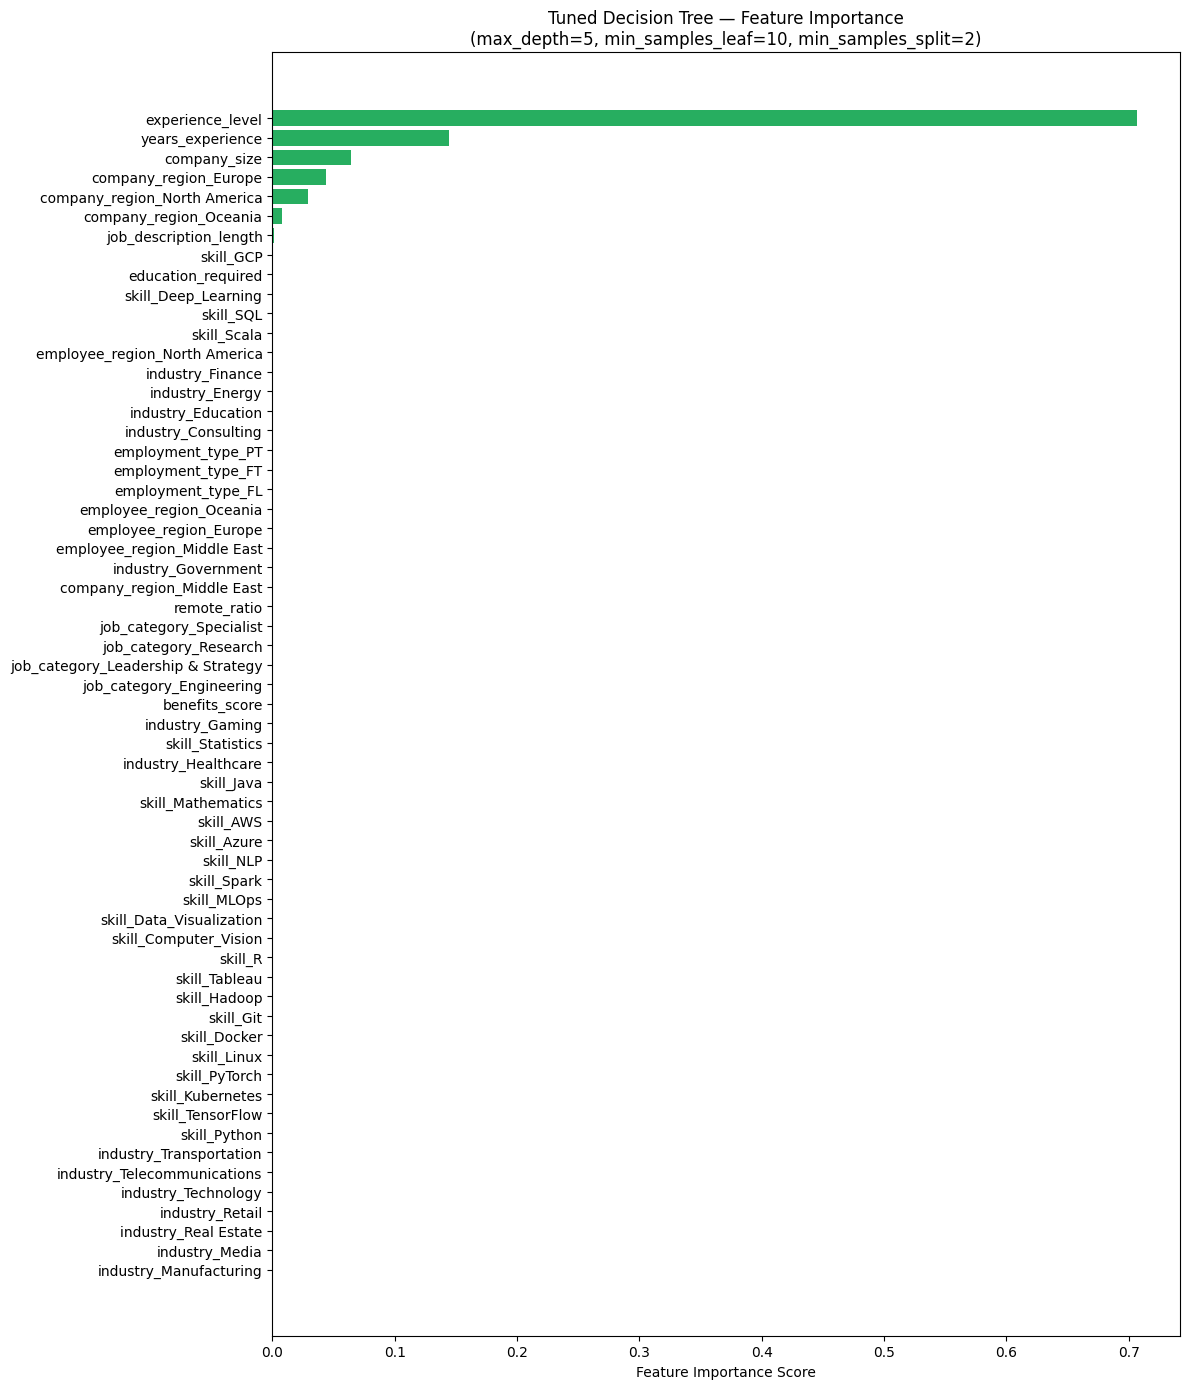

In [35]:
dt_hyper_importance = pd.DataFrame({
    'Feature': x.columns.tolist(),
    'Importance': dt_model_hyper.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 14))
plt.barh(dt_hyper_importance['Feature'], dt_hyper_importance['Importance'], color='#27ae60')
plt.xlabel('Feature Importance Score')
plt.title('Tuned Decision Tree — Feature Importance\n(max_depth=5, min_samples_leaf=10, min_samples_split=2)')
plt.tight_layout()
plt.show()

# Random Forest Implementation
------

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_y_pred = rf_model.predict(x_test)

rf_r2 = r2_score(y_test, rf_y_pred)

print(f'Model Accuracy (R²): {rf_r2 * 100:.2f}%')

Model Accuracy (R²): 67.25%


## Bias / Variance Analysis

Random Forest reduces variance compared to a single Decision Tree by averaging across 100 trees. 

However the gap between training error (~0.05) and Cross Validation error (~0.31) reveals it is still significantly overfitting.

The ensemble helps but does not fully solve the problem without hyperparameter tuning. 

Unlike the untuned Decision Tree though, the Cross Validation error is trending downward with more data, suggesting the model is at least learning generalizable patterns.

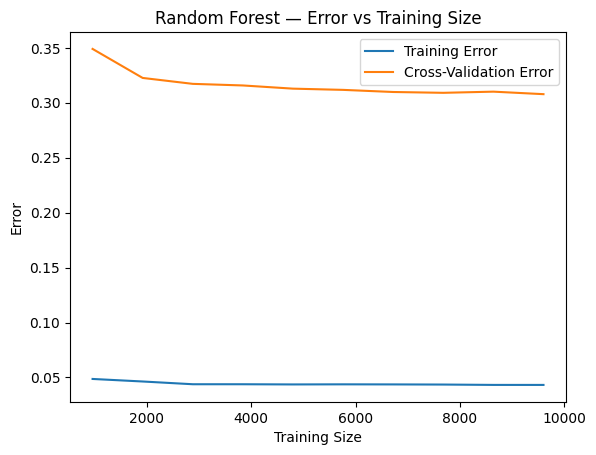

In [38]:
rf_train_sizes, rf_train_scores, rf_valid_scores = learning_curve(
    rf_model, x_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

rf_train_error = 1 - rf_train_scores.mean(axis=1)
rf_valid_error = 1 - rf_valid_scores.mean(axis=1)

plt.figure()
plt.plot(rf_train_sizes, rf_train_error, label='Training Error')
plt.plot(rf_train_sizes, rf_valid_error, label='Cross-Validation Error')
plt.legend()
plt.xlabel('Training Size')
plt.ylabel('Error')
plt.title('Random Forest — Error vs Training Size')
plt.show()

## Feature Importance

Random Forest measures feature importance by calculating how much each feature reduces error across all 100 trees on average. 

This aggregated view is more reliable than a single Decision Tree's importance scores since it reflects 
consistent patterns across many trees rather than one specific path.

Interestingly, the top features mirror both the Linear Regression coefficients and the Tuned Decision Tree — `years_experience` and `experience_level` dominate heavily. 

This **Cross Model agreement** across three fundamentally different algorithms is strong evidence that experience is a genuine salary driver in the AI job market, not an artifact of any single modelling approach.

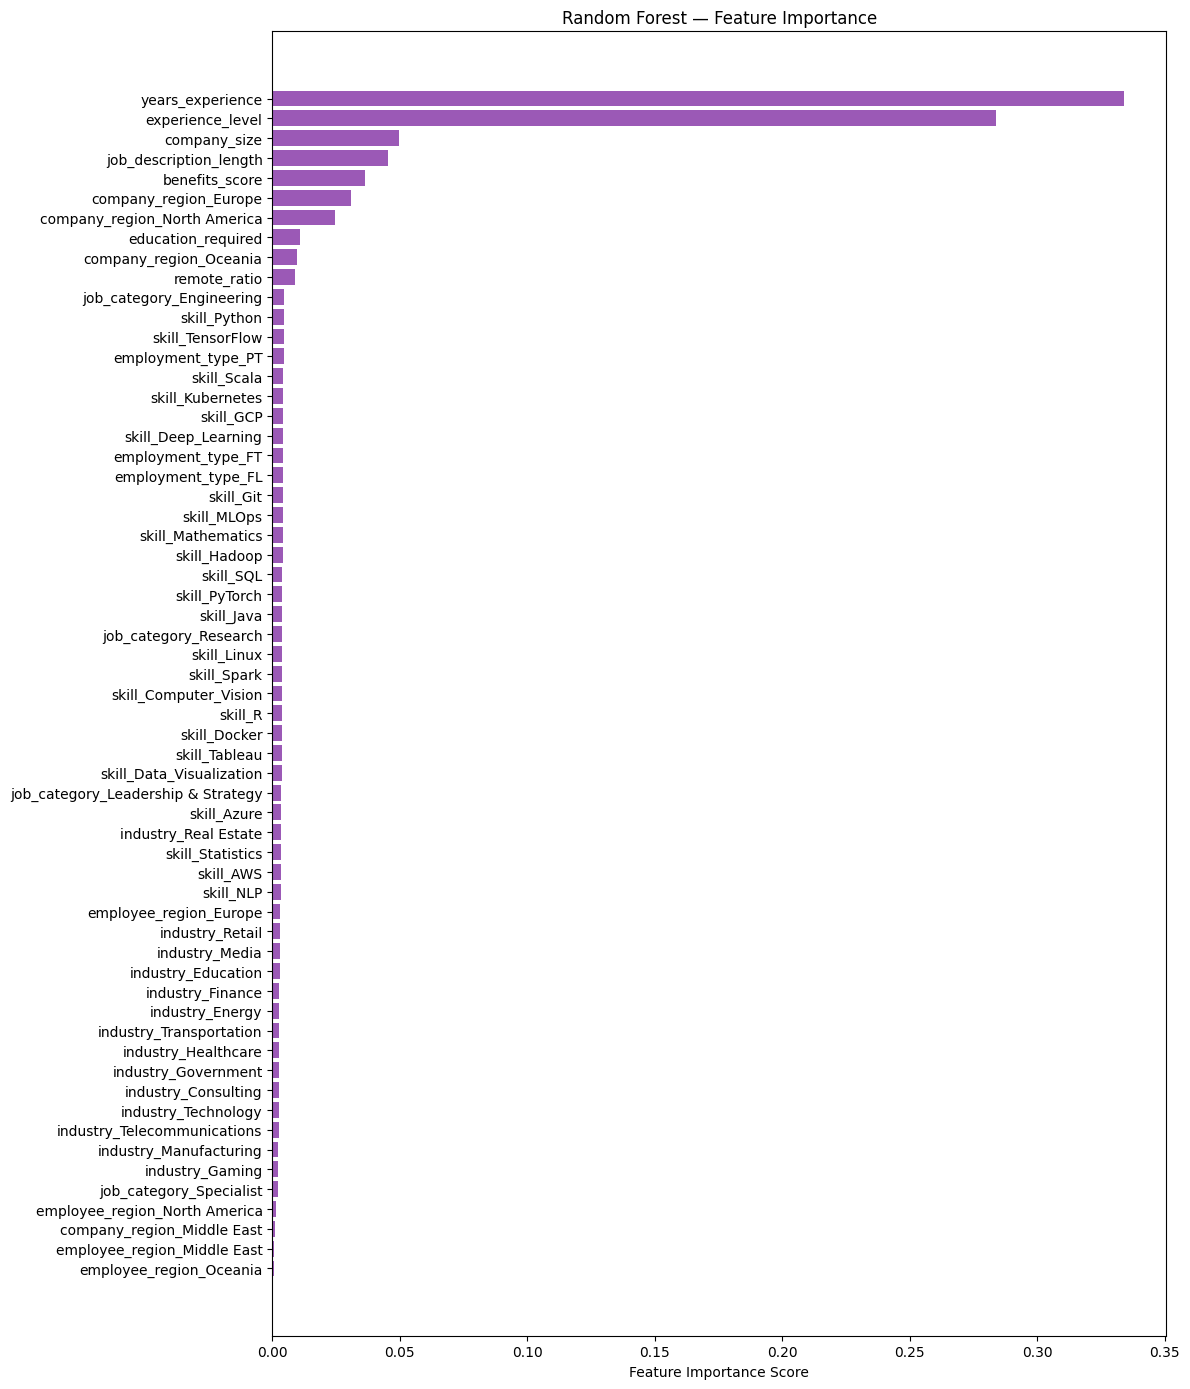

In [39]:
rf_importance = pd.DataFrame({
    'Feature': x.columns.tolist(),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 14))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='#9b59b6')
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

# Saving the Best Model
---

After comparing all models on R2 and generalization behavior, the  **Tuned Decision Tree** is the best performer at **R²=69.43%** with well-converged training and CV errors. 

We save both the model and the scaler — the scaler must be saved alongside the model since any new input data must be transformed the same way before prediction.

In [40]:
import joblib

joblib.dump(dt_model_hyper, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## Single Row Prediction

Using our saved best model, we run a prediction on one sample from the test set to demonstrate real-world usage. 

The model receives the scaled feature vector and outputs a predicted salary in USD.

In [41]:
sample_input = x_test[4].reshape(1, -1)
sample_actual = y_test.iloc[4]

predicted_salary = dt_model_hyper.predict(sample_input)[0]

print(f"Sample Prediction (Tuned Decision Tree)")
print(f"  Actual Salary:    ${sample_actual:,.0f}")
print(f"  Predicted Salary: ${predicted_salary:,.0f}")
print(f"  Difference:       ${abs(predicted_salary - sample_actual):,.0f}")

Sample Prediction (Tuned Decision Tree)
  Actual Salary:    $61,622
  Predicted Salary: $64,015
  Difference:       $2,393


# Conclusion
---

## Model Performance Summary

| Model | R² | Generalizes? |
|---|---|---|
| **Tuned Decision Tree** ✅ | **69.43%** | Yes |
| Linear Regression | 67.61% | Yes |
| Random Forest | 67.25% | Partial |
| Decision Tree (untuned) | 35.05% | No |

## Key Findings

**Experience dominates everything** 

Across all four models and two different importance metrics, `experience_level` and `years_experience` consistently account for the majority of salary predictive power. 

This pattern held whether we used coefficients, tree splits, or ensemble averages — making it the single most reliable finding of this project.

**Geography matters, but it is secondary** 

North America and Europe add a meaningful salary premium, confirmed by both Linear Regression coefficients and tree-based importance scores. 

For aspiring AI professionals in underrepresented regions, remote work represents a real pathway to accessing these higher salary 
brackets.

**Skills have near-zero salary impact** 

Despite 24 skill columns being included, no individual skill — including the big 3 (Python, TensorFlow, or AWS), emerged as a 
meaningful salary predictor. 

What you know matters less than how long you have been doing it.

**Education is surprisingly irrelevant** 

`education_required` ranked near the bottom across all models. 

In the AI job market, demonstrated experience consistently outweighs academic credentials.

**The ~69% ceiling is a data reality, not a model failure.** 

All models converged around the same performance ceiling regardless of architecture. 

This confirms the ceiling is driven by the inherent noise in salary data — factors like negotiation or timing are not added in the data so the models cannot go above this 69% ceiling.

## Implications for the Mission

For a young person in Africa trying to break into the AI industry, this analysis delivers a clear message — 

START BUILDING EXPERIENCE AS EARLY AS POSSIBLE. 

The data shows that seniority and years on the job are the primary drivers of income in this field, far outweighing which 
specific tools you know or which degree you hold. 

The path to a globally competitive AI salary is not about collecting certificates — it is about accumulating real, hands-on experience from day one.